
<style>
  .capa{max-width:920px;margin:16px auto;padding:24px;border:1px solid #e5e7eb;border-radius:12px;font-family:system-ui,-apple-system,"Segoe UI",Roboto,Arial,sans-serif;color:#1f2937}
  .topo{display:flex;gap:16px;align-items:center}
  .logo{width:120px;height:auto;border:1px solid #e5e7eb;border-radius:6px;padding:6px;background:#fff}
  h1{margin:0 0 4px 0;font-size:24px;color:#111827}
  .sub{color:#6b7280;margin-bottom:10px}
  .meta{display:flex;flex-wrap:wrap;gap:8px;margin-bottom:12px}
  .pill{font-size:12px;padding:6px 10px;border:1px solid #e5e7eb;border-radius:999px;background:#f3f4f6}
  hr{border:none;border-top:1px solid #e5e7eb;margin:14px 0}
  h2{font-size:16px;margin:0 0 6px 0;color:#111827}
  ul{margin:6px 0 0 18px}
</style>

<div class="capa" role="region" aria-label="Capa UFMG">
  <div class="topo">
    <img class="logo" src="logo_ufmg.png" alt="Logo UFMG">
    <div>
      <h1>TCC — Análise Descritiva de Preços de Combustíveis (ANP)</h1>
      <div class="sub">Universidade Federal de Minas Gerais — Nota sobre viés e limitações</div>
      <div class="meta">
        <span class="pill">Autoria: <b>Marina Ferreira</b></span>
        <span class="pill">Orientação: <b>Profa. Dra. Jussiane</b></span>
        <span class="pill">Versão 1.0</span>
      </div>
    </div>
  </div>

  <hr>

  <h2>Introdução</h2>
  <p>Este caderno consolida estatísticas descritivas de <em>preços de combustíveis</em> ao longo dos anos,
  com granularidade principal <b>anual</b> e recortes por <b>produto</b> e por <b>espaço</b> (regiões, UFs, municípios).
  O objetivo é apoiar a narrativa de eventos de mercado e políticas públicas que possam ter influenciado
  essas variações.</p>

  <h2>Principais vieses e limitações</h2>
  <ul>
    <li><b>Agregação anual</b> suaviza choques intra-ano; usarei também série mensal.</li>
    <li><b>Cobertura amostral</b> desigual entre UFs/municípios/produtos (impacta comparabilidade).</li>
    <li><b>Rotatividade de postos</b> altera o mix de observações (viés de sobrevivência).</li>
    <li><b>Erros de medição</b> podem persistir mesmo após filtros de outliers.</li>
    <li><b>Tributos e políticas</b> não são controlados automaticamente; interpretar com contexto.</li>
    <li><b>Heterogeneidade espacial</b> (logística/concorrência/renda) afeta níveis de preço.</li>
    <li><b>Composição por produto</b> (ex.: aditivados) influencia médias.</li>
      <li><b>Comparativo de preço de compra com venda</b> não tem registro suficiente de preço de compra e também não tem registro para todos os anos parando em 2020. Por isso a coluna não será usada.</li>
  </ul>

  <h2>Notas metodológicas (resumo)</h2>
  <ul>
    <li>Limpeza monetária (R$) e padronização decimal.</li>
    <li>Cálculos por <em>ano × produto</em> e recortes espaciais; média, mediana, desvio-padrão, p10, p90, IQR e <i>n</i>.</li>
    <li>Outliers por IQR apenas para diagnóstico.</li>
    <li>Mapas com <code>geopandas</code> + <code>geobr</code>; <i>join</i> municipal por nome dentro da UF.</li>
    <li>Série mensal disponível para anotar eventos (políticas/choques).</li>
     <li>Código comentado por IA.</li>
  </ul>
</div>


In [1]:
import pandas as pd
import folium
#import great_expectations
from pathlib import Path
from zipfile import ZipFile
import os
from pathlib import Path
from typing import Optional, Sequence
import re
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from scipy import stats

# Configuração do Notebook
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.options.mode.chained_assignment = None
pd.set_option("display.width", 120)

In [ ]:
def check_cols(df, columns=None):
    """
    Returns a summary of column properties: dtype, unique values, number and percentage of NaNs.

    Parameters:
    - df (pd.DataFrame): The dataframe to inspect.
    - columns (list or None): Subset of columns to check. If None, checks all columns.

    Returns:
    - pd.DataFrame: A summary dataframe sorted by the number of NaN values.
    """
    if columns is None:
        columns = df.columns

    nunique_safe = df[columns].apply(lambda col: col.astype(str).nunique())
    dtypes = df[columns].dtypes
    nans = df[columns].isna().sum()
    percent_nans = round((nans / df.shape[0]) * 100, 2)

    df_check = pd.DataFrame({
        'Variável': columns,
        'Tipo': dtypes,
        'Qtde_unicos': nunique_safe,
        'Qtde_NaN': nans,
        '%_NaN': percent_nans
    })

    return df_check.sort_values('Qtde_NaN').reset_index(drop=True)

def remove_accents(a):
    import unidecode
    return unidecode.unidecode(a.encode().decode('utf-8')).upper().strip()

def normalize_col(c):
    c = str(c).strip()
    c = unicodedata.normalize("NFKD", c).encode("ascii", "ignore").decode("ascii")
    c = c.lower()
    c = re.sub(r"[\s\-\/]+", "_", c)
    c = re.sub(r"[^0-9a-z_]", "", c)
    c = re.sub(r"_+", "_", c).strip("_")
    return c

def extract_all_zips(folder, recursive=True, delete_zip=False):
    """
    Descompacta todos os .zip da pasta (e subpastas se recursive=True).
    Extrai no próprio 'folder'. Opcionalmente remove os .zip após extrair.
    Retorna uma lista de arquivos extraídos.
    """
    base = Path(folder).resolve()
    pattern = "**/*.zip" if recursive else "*.zip"
    extracted = []

    for zpath in sorted(base.glob(pattern)):
        with ZipFile(zpath) as zf:
            # segurança: evita path traversal
            for m in zf.infolist():
                target = (base / m.filename).resolve()
                if not str(target).startswith(str(base)):
                    raise RuntimeError(f"Entrada suspeita no ZIP: {m.filename}")
            zf.extractall(path=base)
            extracted.extend([str((base / m.filename).resolve()) for m in zf.infolist() if m.filename.lower().endswith(".csv")])
        if delete_zip:
            zpath.unlink()
    return extracted

def concatenar_csvs_da_pasta(caminho_da_pasta, nome_arquivo_saida, separador=';', encodings_a_tentar=['utf-8-sig', 'latin1', 'iso-8859-1']):
    """
    Tenta concatenar todos os arquivos CSV de uma pasta, lidando com diferentes
    codificações e erros de formatação nas linhas.

    Args:
        caminho_da_pasta (str): O caminho do diretório contendo os arquivos CSV.
        nome_arquivo_saida (str): O nome do arquivo CSV de saída para salvar o resultado.
        separador (str): O caractere separador dos campos (ponto e vírgula, vírgula, etc.).
        encodings_a_tentar (list): Lista de codificações a serem tentadas.

    Returns:
        pd.DataFrame: O DataFrame pandas resultante da concatenação.
    """
    # Lista para armazenar os DataFrames de cada arquivo CSV
    lista_dataframes = []
    arquivos_com_erro = []

    # Itera sobre todos os arquivos no diretório
    for arquivo in os.listdir(caminho_da_pasta):
        # Verifica se o arquivo é um CSV
        if arquivo.endswith('.csv'):
            caminho_completo_arquivo = os.path.join(caminho_da_pasta, arquivo)
            print(f'Lendo o arquivo: {caminho_completo_arquivo}')
            
            df_temporario = None
            leitura_bem_sucedida = False
            
            # Tenta ler o arquivo com diferentes codificações
            for encoding in encodings_a_tentar:
                try:
                    df_temporario = pd.read_csv(
                        caminho_completo_arquivo,
                        encoding=encoding,
                        sep=separador,
                        on_bad_lines='skip', # Ignora linhas com erros de formatação
                        low_memory=False # Ajuda a evitar erros de tipo em datasets grandes
                    )
                    lista_dataframes.append(df_temporario)
                    print(f"Sucesso com o separador '{separador}' e codificação '{encoding}'.")
                    leitura_bem_sucedida = True
                    break # Sai do loop de encodings se a leitura foi bem-sucedida
                except Exception as e:
                    continue # Tenta a próxima codificação se houver um erro

            if not leitura_bem_sucedida:
                print(f"Falha ao ler o arquivo {arquivo} com os parâmetros fornecidos.")
                arquivos_com_erro.append(arquivo)
                
    # Verifica se a lista de DataFrames não está vazia
    if not lista_dataframes:
        print("Nenhum arquivo CSV pôde ser lido na pasta.")
        return pd.DataFrame()

    # Concatena todos os DataFrames da lista em um único DataFrame
    df_final = pd.concat(lista_dataframes, ignore_index=True)
    print(f'\nConcluído! {len(lista_dataframes)} arquivos foram lidos e concatenados.')
    print(f'O DataFrame final tem {len(df_final)} linhas.')
    
    if arquivos_com_erro:
        print(f"Os seguintes arquivos não puderam ser lidos: {', '.join(arquivos_com_erro)}")

    # Salva o DataFrame final em um novo arquivo CSV
    df_final.to_csv(nome_arquivo_saida, index=False)
    print(f'O DataFrame concatenado foi salvo em: {nome_arquivo_saida}')

    return df_final



# Função para criar e salvar gráficos de barras
def plot_bar_chart(df, group_col, value_col, title, filename):
    import seaborn as sns
    plt.figure(figsize=(12, 8))
    # Agrupar e somar os valores para plotagem
    grouped_data = df.groupby(group_col)[value_col].sum().sort_values(ascending=False)
    sns.barplot(x=grouped_data.index, y=grouped_data.values, palette='viridis')
    plt.title(title)
    plt.xlabel(group_col)
    plt.ylabel(f'Soma do {value_col}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(filename)
    plt.close()

Dados:  </br>
https://www.gov.br/anp/pt-br/assuntos/precos-e-defesa-da-concorrencia/precos/levantamento-de-precos-de-combustiveis-ultimas-semanas-pesquisadas </br>
-> serie historica https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/serie-historica-de-precos-de-combustiveis

In [ ]:
from pathlib import Path


def read_parquet_smart(path_or_dir: str, filename: str | None = None):
    # tenta pyarrow; cai para fastparquet
    try:
        import pyarrow  # noqa
        engine = "pyarrow"
    except Exception:
        engine = "fastparquet"

    p = Path(path_or_dir).expanduser().resolve()

    # 1) Se path_or_dir já é um arquivo .parquet → lê direto
    if p.is_file() and p.suffix.lower() == ".parquet":
        df = pd.read_parquet(p, engine=engine)
        print(f"[OK] Lido arquivo: {p} ({engine})")
        return df

    # 2) Se for diretório:
    if p.is_dir():
        if filename:  # arquivo específico dentro da pasta
            alvo = p / filename
            if alvo.exists():
                df = pd.read_parquet(alvo, engine=engine)
                print(f"[OK] Lido arquivo: {alvo} ({engine})")
                return df
        # 2b) dataset particionado (pasta parquet) com o nome sem .parquet
        if filename and (p / filename.replace(".parquet", "")).is_dir():
            df = pd.read_parquet(p / filename.replace(".parquet", ""), engine=engine)
            print(f"[OK] Lido dataset particionado: {p/filename.replace('.parquet','')} ({engine})")
            return df
        # 2c) senão, pega o primeiro .parquet da pasta
        candidatos = sorted(p.glob("*.parquet"))
        if candidatos:
            df = pd.read_parquet(candidatos[0], engine=engine)
            print(f"[OK] Lido primeiro parquet da pasta: {candidatos[0]} ({engine})")
            return df
        raise FileNotFoundError(f"Nenhum .parquet encontrado em: {p}")

    raise FileNotFoundError(f"Caminho inválido (não é arquivo .parquet nem pasta): {p}")


In [ ]:
pasta = "/home/mari/tcc_lubricants_anp"
arquivo = "lubricants_anp_full.parquet"
df_raw = read_parquet_smart(pasta, filename=arquivo)

[OK] Lido arquivo: /home/mari/tcc_lubricants_anp/lubricants_anp_full.parquet (pyarrow)


In [ ]:
df_raw = df_raw.loc[:, ~df_raw.columns.str.match(r"^Unnamed")]

In [ ]:
df = df_raw.copy()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7422035 entries, 0 to 7422034
Data columns (total 16 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   Regiao - Sigla     object
 1   Estado - Sigla     object
 2   Municipio          object
 3   Revenda            object
 4   CNPJ da Revenda    object
 5   Nome da Rua        object
 6   Numero Rua         object
 7   Complemento        object
 8   Bairro             object
 9   Cep                object
 10  Produto            object
 11  Data da Coleta     object
 12  Valor de Venda     object
 13  Valor de Compra    object
 14  Unidade de Medida  object
 15  Bandeira           object
dtypes: object(16)
memory usage: 906.0+ MB


In [ ]:
df.sample(5)

,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
3757572,SE,SP,OSASCO,AUTO POSTO MARGINAL DA CASTELO LTDA,00.268.096/0001-73,AVENIDA PRES KENNEDY,3411,None,ROCHDALE,06298-190,GASOLINA,25/04/2023,"5,49",None,R$ / litro,VIBRA ENERGIA
568505,NE,CE,SOBRAL,POSTO SAO DOMINGOS LTDA,69.366.128/0001-70,AVENIDA DOUTOR GUARANY,854,None,DERBY CLUB,62040-730,DIESEL,14/08/2017,"3,29","2,7699",R$ / litro,RAIZEN
3004081,S,PR,COLOMBO,MIRAGE COMERCIO DE COMBUSTIVEIS LTDA,14.748.153/0001-26,RUA ALFREDO TOMACHESCHI,50,None,GUARAITUBA,83407-330,GASOLINA,17/01/2022,"6,29",None,R$ / litro,IPIRANGA
3465224,S,RS,RIO GRANDE,ABASTECEDORA DE COMBUSTIVEIS PORTUGAL LTDA,15.054.918/0001-90,AVENIDA PORTUGAL,SN,ESQ.MJ CARLOS PINTO,CIDADE NOVA,96211-011,GASOLINA,22/06/2022,"6,99",None,R$ / litro,IPIRANGA
4275568,SE,RJ,RIO DE JANEIRO,AUTO POSTO RECANTO DAS PALMEIRAS LTDA,06.031.327/0001-07,RUA PINTOR LEANDRO JOAQUIM,11,CIDADE DE DEUS,JACAREPAGUA,22770-650,GNV,02/12/2024,"4,46",None,R$ / m³,RAIZEN


In [ ]:
check_cols(df, df.columns)

,Variável,Tipo,Qtde_unicos,Qtde_NaN,%_NaN
0,Regiao - Sigla,object,6,9114,0.12
1,Estado - Sigla,object,28,9114,0.12
2,Municipio,object,528,9114,0.12
3,Revenda,object,21642,9114,0.12
4,CNPJ da Revenda,object,23853,9114,0.12
5,Nome da Rua,object,13761,9114,0.12
6,Produto,object,7,9114,0.12
7,Cep,object,15864,9114,0.12
8,Bandeira,object,97,9114,0.12
9,Unidade de Medida,object,3,9114,0.12


In [ ]:
df.head(1)

,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
0,SE,SP,SOROCABA,COMPETRO COMERCIO E DISTRIBUICAO DE DERIVADOS ...,00.003.188/0001-21,RUA HUMBERTO DE CAMPOS,306,None,JARDIM ZULMIRA,18061-000,GASOLINA,03/07/2023,"4,87",None,R$ / litro,BRANCA


In [ ]:
# clean
df['Valor de Venda'] = df['Valor de Venda'].str.replace(',', '.', regex=True).astype(float)
df['Data da Coleta'] = pd.to_datetime(df['Data da Coleta'], format='%d/%m/%Y')
df['Ano'] = df['Data da Coleta'].dt.year

Bloco de análise

In [ ]:
rename = {
    "Regiao - Sigla":"regiao","Estado - Sigla":"estado","Municipio":"municipio",
    "Produto":"produto","Bandeira":"bandeira","Data da Coleta":"data",
    "Valor de Venda":"valor_venda","Valor de Compra":"valor_compra"
}
df.rename(columns={c: rename.get(c, c) for c in df.columns}, inplace=True)

In [ ]:
df.head(1)

,regiao,estado,municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,produto,data,valor_venda,valor_compra,Unidade de Medida,bandeira,Ano
0,SE,SP,SOROCABA,COMPETRO COMERCIO E DISTRIBUICAO DE DERIVADOS ...,00.003.188/0001-21,RUA HUMBERTO DE CAMPOS,306,None,JARDIM ZULMIRA,18061-000,GASOLINA,2023-07-03,4.87,None,R$ / litro,BRANCA,2023.0


In [ ]:
df["data"] = pd.to_datetime(df["data"], dayfirst=True, errors="coerce")
df = df.dropna(subset=["data", "valor_venda", "estado", "produto", "bandeira"]).copy()

In [ ]:
def _to_float_bra(s):
    if s is None: return np.nan
    x = str(s).strip()
    if x == "" or x.lower() in {"nan","none","null"}: return np.nan
    if "," in x and "." in x:
        x = x.replace(".", "").replace(",", ".")
    elif "," in x:
        x = x.replace(",", ".")
    try: return float(x)
    except: return np.nan

for c in ["preco_venda", "preco_compra"]:
    if not np.issubdtype(df[c].dtype, np.number):
        df[c] = df[c].apply(_to_float_bra)

In [ ]:
df = df[(df["data"] >= "2017-01-01") & (df["data"] <= "2025-08-31")].copy()
df["ano_mes"] = df["data"].dt.to_period("M").astype(str)
df["ano"] = df["data"].dt.year

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7412921 entries, 0 to 7422034
Data columns (total 19 columns):
 #   Column             Dtype         
---  ------             -----         
 0   regiao             object        
 1   estado             object        
 2   municipio          object        
 3   Revenda            object        
 4   CNPJ da Revenda    object        
 5   Nome da Rua        object        
 6   Numero Rua         object        
 7   Complemento        object        
 8   Bairro             object        
 9   Cep                object        
 10  produto            object        
 11  data               datetime64[ns]
 12  valor_venda        float64       
 13  valor_compra       object        
 14  Unidade de Medida  object        
 15  bandeira           object        
 16  Ano                float64       
 17  ano_mes            object        
 18  ano                int32         
dtypes: datetime64[ns](1), float64(2), int32(1), object(15)
memory usage:

In [19]:

def to_float_bra(x):
    s = str(x).strip()
    if s == "" or s.lower() in {"nan","none","null"}: return np.nan
    if "," in s and "." in s: s = s.replace(".", "").replace(",", ".")
    elif "," in s: s = s.replace(",", ".")
    try: return float(s)
    except: return np.nan

for c in ["valor_venda","valor_compra"]:
    if c in df.columns and not np.issubdtype(df[c].dtype, np.number):
        df[c] = df[c].apply(to_float_bra)

df = df.loc[(df["data"] >= "2017-01-01") & (df["data"] <= "2025-08-31")].copy()



In [20]:
# ---- 2) Agregar para valor único SEMANAL por combustível ----
# Semana começando na segunda-feira
df["sem_dt"] = df["data"].dt.to_period("W-MON").apply(lambda p: p.start_time)

agg_w = (
    df.groupby(["produto","sem_dt"], as_index=False)
      .agg(
          n=("valor_venda","size"),
          venda_media=("valor_venda","mean"),
          venda_mediana=("valor_venda","median"),
          compra_media=("valor_compra","mean"),
          compra_mediana=("valor_compra","median"),
      )
      .sort_values(["produto","sem_dt"])
)

# margem semanal (com base nas medianas — robusto)
agg_w["margem_mediana"] = agg_w["venda_mediana"] - agg_w["compra_mediana"]

TARGET = "venda_mediana"   # ou 'venda_media' se preferir

In [21]:
# ---- 3) Features de tempo + split temporal ----
t0 = agg_w["sem_dt"].min()
agg_w["t"] = (agg_w["sem_dt"] - t0).dt.days.astype("int32")

In [23]:
# Sazonalidade semanal via Fourier (período ≈ 52.18 semanas)
# Poucos termos (K=3) para não explodir parâmetros
def add_fourier(df, t_col, period=365.25, K=3, prefix="F"):
    tt = df[t_col].astype("float64")
    for k in range(1, K+1):
        df[f"{prefix}_sin{k}"] = np.sin(2*np.pi*k*tt/period)
        df[f"{prefix}_cos{k}"] = np.cos(2*np.pi*k*tt/period)
    return df

agg_w = add_fourier(agg_w, "t", period=365.25, K=3, prefix="W")

cutoff = pd.Timestamp("2024-12-31")
train = agg_w.loc[agg_w["sem_dt"] <= cutoff].copy()
test  = agg_w.loc[agg_w["sem_dt"] >  cutoff].copy()

# alvo em log
train = train.loc[train[TARGET] > 0].copy()
test  = test.loc[test[TARGET] > 0].copy()
train["log_y"] = np.log(train[TARGET])
test["log_y"]  = np.log(test[TARGET])

print(f"Treino semanal: {train['sem_dt'].min().date()} → {train['sem_dt'].max().date()} | linhas={len(train):,}")
print(f"Teste  semanal: {test['sem_dt'].min().date()} → {test['sem_dt'].max().date()}  | linhas={len(test):,}")

Treino semanal: 2016-12-27 → 2024-12-31 | linhas=2,276
Teste  semanal: 2025-01-07 → 2025-06-24  | linhas=150


In [24]:
# ---- 4) Modelo linear (leve) ----
# tendência (t) + Fourier semanal (3 harmônicos) + efeito fixo de produto
fourier_terms = " + ".join([f"W_sin{k} + W_cos{k}" for k in range(1,4)])
formula = f"log_y ~ t + {fourier_terms} + C(produto)"

mod = smf.ols(formula, data=train).fit(cov_type="HC3")
print(mod.summary())


                            OLS Regression Results                            
Dep. Variable:                  log_y   R-squared:                       0.793
Model:                            OLS   Adj. R-squared:                  0.792
Method:                 Least Squares   F-statistic:                     1109.
Date:                Tue, 07 Oct 2025   Prob (F-statistic):               0.00
Time:                        22:29:05   Log-Likelihood:                 1420.8
No. Observations:                2276   AIC:                            -2816.
Df Residuals:                    2263   BIC:                            -2741.
Df Model:                          12                                         
Covariance Type:                  HC3                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

In [27]:
# ---- 5) Avaliação no teste (voltando ao nível) ----
pred_log = mod.predict(test)                 # Series alinhada pelo index de 'test'
yhat = np.exp(pred_log)                      # mantém o mesmo index
y = test[TARGET]                             # Series alinhada

# métricas com alinhamento seguro
idx = y.index.intersection(yhat.index)
mae  = (yhat.loc[idx] - y.loc[idx]).abs().mean()
rmse = np.sqrt(((yhat.loc[idx] - y.loc[idx])**2).mean())
mape = ((yhat.loc[idx] - y.loc[idx]).abs() / y.loc[idx]).mean() * 100
print(f"\n[TESTE semanal 2025-01..08] {TARGET}: MAE={mae:.3f}  RMSE={rmse:.3f}  MAPE={mape:.2f}%")

# anexa ao DataFrame para facilitar os plots
test = test.assign(y_obs=y, y_hat=yhat)




[TESTE semanal 2025-01..08] venda_mediana: MAE=0.584  RMSE=0.655  MAPE=10.53%


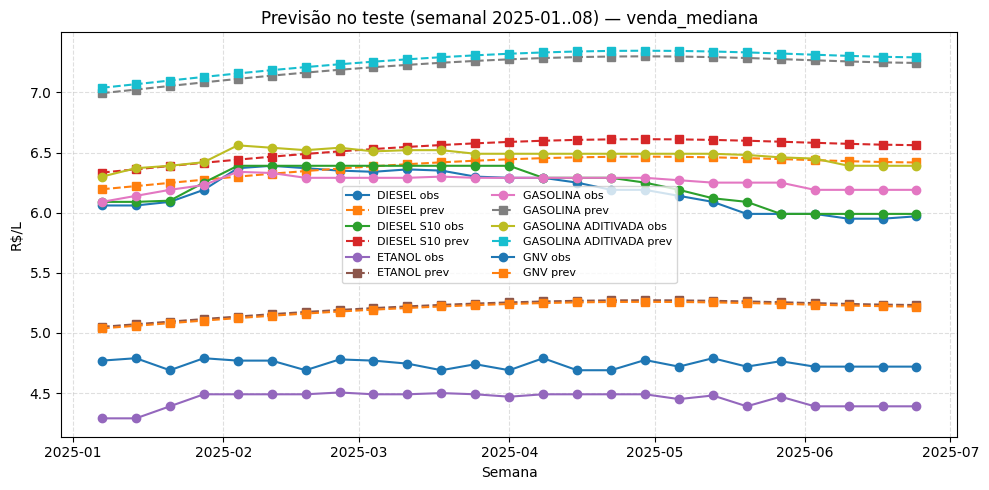

In [28]:
# ---- 6) Gráficos (alinhados) ----
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
for prod, g in test.groupby("produto"):
    g = g.sort_values("sem_dt")
    plt.plot(g["sem_dt"], g["y_obs"], marker="o", label=f"{prod} obs")
    plt.plot(g["sem_dt"], g["y_hat"], marker="s", linestyle="--", label=f"{prod} prev")
plt.title(f"Previsão no teste (semanal 2025-01..08) — {TARGET}")
plt.ylabel("R$/L"); plt.xlabel("Semana"); plt.grid(True, linestyle="--", alpha=.4)
plt.legend(ncol=2, fontsize=8); plt.tight_layout(); plt.show()

In [29]:
# métricas in-sample (treino)
pred_tr = np.exp(mod.predict(train))
y_tr = train[TARGET]
mae_tr  = (pred_tr - y_tr).abs().mean()
rmse_tr = np.sqrt(((pred_tr - y_tr)**2).mean())
mape_tr = ((pred_tr - y_tr).abs() / y_tr).mean() * 100
print(f"TREINO: MAE={mae_tr:.3f} RMSE={rmse_tr:.3f} MAPE={mape_tr:.2f}%")

# baseline 1: “naive semanal” (repete valor da semana anterior por produto)
test_sorted = test.sort_values(["produto","sem_dt"]).copy()
test_sorted["y_naive1"] = test_sorted.groupby("produto")[TARGET].shift(1)
base_mae  = (test_sorted["y_naive1"] - test_sorted[TARGET]).abs().mean()
base_rmse = np.sqrt(((test_sorted["y_naive1"] - test_sorted[TARGET])**2).mean())
base_mape = ((test_sorted["y_naive1"] - test_sorted[TARGET]).abs() / test_sorted[TARGET]).mean()*100
print(f"BASELINE (lag1): MAE={base_mae:.3f} RMSE={base_rmse:.3f} MAPE={base_mape:.2f}%")


TREINO: MAE=0.472 RMSE=0.651 MAPE=9.94%
BASELINE (lag1): MAE=0.029 RMSE=0.048 MAPE=0.54%
